<a href="https://colab.research.google.com/github/chaitragopalappa/MIE590-690D/blob/main/4_PINN/2d_NeuralODE_Non_Autonomous.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem setting- using Epidemic example
## State variables
- $x_1(t)$: susceptible population,
- $x_2(t)$: mildly infectious individuals,
- $x_3(t)$: hospitalized or severe infections,
- $x_4(t)\in[0,1]$: public compliance level.

## Inputs
- $\beta_0$: Baseline transmission rate.
- $\beta_e$: Effective transmission rate (accounting for changes in behavior from compliance  $x_4$.
- $U_{ac}(t)$: Healthcare resource allocation rate.
- $T_u$: Intervention response time
- $T_p$: Healthcare system response time.
- $T_f$: Behavioral adaptation time.
- $T_p$ and $T_f$ are assumed proportional to $T_u$.
- $\gamma_h$ is the hospitalization rate.
----


## Ordinary Differential Equations
$$\dot{x}_1 = \beta_e(t)\frac{x_1x_2}{N} +   \frac{x_2}{T_u} + \frac{x_3}{T_p}$$
$$\dot{x}_2= -\gamma_hx_2 - \frac{x_2}{T_u} +\beta_e(t)\frac{x_1x_2}{N}$$

$$\dot{x}_3=-\frac{x_3}{T_p}+\gamma_h x_2$$

$$\dot{x}_4=\frac{f_s(R_p)-x_4}{T_f}$$

where
$$\text{Effective Transmission Rate:} \beta_e(t)= -\beta_0\left(1-\eta x_4(t)\right) \qquad
0\le \eta \le 1$$
$$\text{Perceived Epidemic risk:} R_p(t)=w_1x_2(t)+w_2x_3(t).$$

$$ \text{Behavioral adaptation:} f_s(R_p)=\frac{1}{1+\exp\left[-k\left(R_p-R_c\right)\right]}$$

$$\text{Intervention Time Constants }
T_u(t)=\frac12\min\left(\frac{c}{U(t)},100\right)
,\qquad
T_p=T_{p,0}T_u,\qquad
T_f=T_{f,0}T_u
,\qquad
where, \qquad
T_{p,0}=1.5,\qquad
T_{f,0}=6.
$$


## Assume:
- We do not know $\beta_0$
- We do not know functional form of $f_s(R_p)$, or $R_p$.
- We know functional form of $\dot{x_1}, \dot{x_2}, \dot{x_3}$, and $\dot{x_4}$ ( $\dot{x_4}$ limited by unknown $f_s(.)$)
- We know functional form of $T_p$, and $T_f$ but not functional form of $T_u(t)$.
- Consider three cases for $U(t)$
  - CASE A — we HAVE data for $U(t)$.
  - CASE B — we DON'T have $U(t)$ values, but we KNOW the intervention change-points (times $t$).
  - CASE C — we know NEITHER $U(t)$ NOR the intervention change-points (dates/times)
  ---
  ---



# OBJECTIVE:
Use NODE to
- learn $\beta_0$
- learn functional form of $f_s=f(t,x,u(t))$
- learn $T_u=f(t)$ ;(code has been setup as $T_u=f(x,u(t))$ could probably change)

- Use following approach for the three cases for $U(t)$
  - CASE A — we HAVE data for $U(t)$: treat it as a known interpolated signal fed directly into the neural networks for learning fs and Tu.
  - CASE B — we DON'T have $U(t)$ values, but we KNOW the intervention change-points (times $t$): parameterize $U(t)$ as a learnable piecewise-constant step function with fixed breakpoints.
  - CASE C — we know NEITHER $U(t)$ NOR the intervention change-points (dates/times): augment the ODE state with a learned latent variable z whose own dynamics are inferred purely from fitting $x(t)$; fs and Tu become functions of z.
  This is a "latent-ODE-flavored" solution, minus the ODE-RNN or variational autoencoder in Chen et. al. (2018) or Rubanova et al. (2019).https://arxiv.org/pdf/1907.03907


# APPROACH: Non-Autonomous/Forced NODEs (Neural ODEs)

In non-autonoumous or forced Neural ODEs (NODEs), we have
$$\frac{dx}{dt}​=f(t,x,u(t)) $$
where $u(t)$ is some external, exogenous signal (policy stringency, mobility, vaccination rate, etc.) that isn't part of the state $x$ itself but still drives the dynamics.

Here we look at cases where the following assumptions hold
- The observations of  $x$  available for training reflect the effect of $u(t)$.
- The initial_point $x_0$ is fixed (does not need to change midway into ODE solver)
- The mechanistics of $u(t)$ on the state  $x(t)$ can be fully learnt into the differntial equations  (though the mathematical form are known)
- Once training is complete forecasting future projections of $x(t)$ can be done with learned model. That is, the forcasted state will match the actual state, no other exogenous parameters apart from the learned relation between $\dot{x}$ and $u(t)$ will cause a state jump.  

More formally, from Chen et.al., 2019" Function $f$ is a time-invariant function that takes the value $u$ at the current time step and outputs the gradient: $∂u(t)/∂t = f (u(t), θ_f )$. We can parametrize this function using a neural net. Because $f$ is time-invariant, given any latent state $u(t)$, the entire latent trajectory is uniquely defined. Extrapolating this latent trajectory lets us make predictions arbitrarily far forwards or backwards in time."

We will look at three cases:
1) We know $u(t)$
2) We do not know $u(t)$ but know at what time points it changes
3) We do not know $u(t)$ nor the time points it changes (treat as augmented state)

Source:
- (Non-Autonomous NODE) Davis, J.Q., et al. (2020). Time Dependence in Non-Autonomous Neural ODEs. https://arxiv.org/abs/2005.01906

- (Non-Autonomy, and Latent  --> Section 2.2 and 2.3)  Kidger, P. (2022). On Neural Differential Equations (Oxford doctoral thesis). https://arxiv.org/abs/2202.02435  


#  Future options: Latent NODE

- Case C: uses an augmented state to learn the latent variable
- A better approach: NODE-RNN and Latent NODE use  VAE mechanism: - Rubanova, Chen, Duvenaud (2019), Latent ODEs for Irregularly-Sampled Time Series, NeurIPS 2019. arXiv:1907.03907  

## Future options: Neural CDEs
Note: Non-autonomous/forced/latent Neural ODEs are different than Neural Controlled Differential Equations (Neural CDE) where $$\frac{dx}{dt}​=f(t,x)\frac{du}{dt} $$, where RHS is a  matrix-vector multiplication.
- While Neural ODEs are continuous equivalent of ResNet(Residual Network), CDEs are continuous equivalent of RNN (Recurrent Neural Network). ResNet is a feed-forward Convolutional Neural Network (CNN) designed for spatial data. RNN is an architecture for sequential/temporal data (like text or time series) that processes inputs one by one, retaining memory of previous steps.
CDE Source:
- Kidger, P., Morrill, J., Foster, J., & Lyons, T. (2020). Neural Controlled Differential Equations for Irregular Time Series. NeurIPS 2020 (Spotlight). arXiv:2005.08926
https://arxiv.org/abs/2005.08926

- Kidger, P. (2022). On Neural Differential Equations (Oxford doctoral thesis). https://arxiv.org/abs/2202.02435

- Morrill, J., Kidger, P., Yang, L., & Lyons, T. (2021). Neural Controlled Differential Equations for Online Prediction Tasks. https://arxiv.org/abs/2106.11028   

## Survey for NODEs, NCDEs and NSDEs (Neural Stochastic Differential Equations)
YongKyung Oh, et. al., Comprehensive Review of Neural Differential Equations for Time Series Analysis, 2025 https://arxiv.org/pdf/2502.09885




# APPLY  NODE/ UDE

In [1]:
!pip install torchdiffeq
!pip install torchcde
!pip install torch-cubic-spline-grids
!pip install torchcde

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 8.0 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
#from torchdiffeq import odeint_adjoint  # note use of adjoint v regular backprop
from torchdiffeq import odeint
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
import torchcde   # note use of adjoint v regular backprop


## GPU Setup

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [4]:
# Initial populations: S=0.99, I=0.01, E=0.00
initial_state = torch.tensor([0.99, 0.01, 0.00, 0.00], dtype=torch.float32).to(device)
t_data = torch.linspace(0., 100., 500).to(device)  # 500 time points from t=0 to t=100

#U(t)
obs_times = torch.tensor([0.0, 15.0, 30.0, 45.0, 60.0, 75.0, 90.0]).to(device)
obs_u = torch.tensor([100, 10, 40,  100, 20,  20, 100], dtype=torch.float32).to(device)  # e.g. stringency index


N=1
eta= 0.8

Tf_0 = 6
Tp_0 = 1.5
gamma_h=0.02
Rc = 0.5 # (0 to 1; is the risk threshold at which the population begins substantially changing behavior.
k = 5 #controls how rapidly behavior changes around that threshold;

#unknowns;
    #beta is unknown
    #functional form of fs and Tu are unknown
    #U(t), and Tu, Tf, Tp are unknown in Case B and C.

#Generate true data (or upload true data)

In [5]:
class LinearInterpolator:
    """Minimal u(t) interpolator from observed (times, values).
    Swap for torchcde.natural_cubic_coeffs(...) if you want smooth
    derivatives through u(t) (recommended for adjoint-based backprop)."""
    def __init__(self, times: torch.Tensor, values: torch.Tensor):
        self.times = times.to(device)          # (T,) sorted ascending
        self.values = values.to(device)        # (T,)

    def __call__(self, t):
        # t: scalar tensor (odeint calls forward(t, x) with scalar t)
        t = t.clamp(self.times[0], self.times[-1])
        idx = torch.searchsorted(self.times, t).clamp(1, len(self.times) - 1)
        t0, t1 = self.times[idx - 1], self.times[idx]
        v0, v1 = self.values[idx - 1], self.values[idx]
        w = (t - t0) / (t1 - t0 + 1e-8)
        return (v0 + w * (v1 - v0)).reshape(1)  # shape (1,)

In [6]:

class CubicSplineInterpolator:
    def __init__(self, times, values):
        self.times = times.to(device)

        x = values.to(device).reshape(1, -1, 1)

        coeffs = torchcde.natural_cubic_coeffs(
            x,
            t=self.times
        )

        self.spline = torchcde.CubicSpline(coeffs)

    def __call__(self, t):
        t = t.clamp(self.times[0], self.times[-1])
        return self.spline.evaluate(t).squeeze(0)

In [7]:
def true_sir_dynamics(t, x):
    beta = 0.3# this is unknown
    x1,x2,x3,x4 = x[0], x[1], x[2], x[3]
    #functional form of fs is unknown
    Rp = 0.2 * x2 + 0.8 * x3 # Perceived epidemic risk
    fs = 1.0 / (1.0 + torch.exp(-k * (Rp - Rc))) # Use torch.exp for device compatibility
    u_interp = LinearInterpolator(obs_times, obs_u)
    #u_interp = CubicSplineInterpolator(obs_times, obs_u)

    Tu = (1/2) * min(u_interp(t).item(), 100) # Original problematic line
    #Tu = (1/2) * torch.min(u_interp(t), torch.tensor(100.0, device=device)) # Corrected to use torch.min
    Tp=Tp_0*Tu
    Tf=Tf_0*Tu
    dx1dt = -beta * (1 - eta * x4) * x1 * x2 / N + x2 / Tu + x3 / Tp
    dx2dt = -gamma_h * x2 - x2 / Tu + beta * (1 - eta * x4) * x1 * x2 / N
    dx3dt = -x3 / Tp + gamma_h * x2
    dx4dt = -  x4 / Tf + fs/Tf
    return torch.stack([dx1dt, dx2dt, dx3dt, dx4dt])

with torch.no_grad():
    true_x = odeint(true_sir_dynamics, initial_state, t_data).to(device)

batch_time_steps = 30  # Slicing window size for stabilization
total_steps = t_data.size(0)

# PHYSICS TO USE IN TRAIN

In [8]:
def _split_state(x):
    """x: (..., 4) -> x1,x2,x3,x4 each (..., 1)"""
    x_in = x.unsqueeze(0) if x.dim() == 1 else x
    return x_in, x_in[:, 0:1], x_in[:, 1:2], x_in[:, 2:3], x_in[:, 3:4]


def _epidemic_rhs(beta0, eta, x1, x2, x3, x4, fs, Tu, gamma_h, Tp, Tf, N):
    #beta is unknown
    #functional form of fs is unknown
    #U(t), and Tu, Tf, Tp are unknown in Case B and C.
    dx1dt = -beta0 * (1 - eta * x4) * x1 * x2 / N + x2 / Tu + x3 / Tp
    dx2dt = -gamma_h * x2 - x2 / Tu + beta0 * (1 - eta * x4) * x1 * x2 / N
    dx3dt = -x3 / Tp + gamma_h * x2
    dx4dt = - x4 /Tf + fs/Tf
    return torch.cat([dx1dt, dx2dt, dx3dt, dx4dt], dim=1)

# ODEfunc setup for Cases A, B, C
''CASE A — we HAVE data for u(t): treat it as a known, interpolated signal fed directly into the networks for fs and Tu.

CASE B — we DON'T have u(t) values, but we KNOW the intervention change-points (dates/times): parameterize u as a learnable piecewise-constant step function with fixed breakpoints.

CASE C — we know NEITHER u(t) NOR the intervention change-points (dates/times): augment the ODE state with a learned latent variable z whose own dynamics are inferred purely from fitting x(t); fs and Tu become functions of z.
  This is a "latent-ODE-flavored" solution, minus the ODE-RNN or variational autoencoder in Chen et. al. (2018) or Rubanova et al. (2019).https://arxiv.org/pdf/1907.03907

In [9]:
# ===========================================================================
# CASE A: u(t) is observed data -> interpolate it, feed as forcing input
# ===========================================================================
class ODEFunc_CaseA(nn.Module):
    """u(t) known -> non-autonomous / controlled ODE: forcing signal is an
    extra input to the networks that produce fs and Tu."""
    def __init__(self, u_interp: LinearInterpolator):
        super().__init__()

        self.u_interp = u_interp
        self.beta = nn.Parameter(torch.tensor(0.2, dtype=torch.float32).to(device))

        # map: x1,x2,x3,x4,u(t)  -> f; 5 features to 1 feature
        self.net_fs = nn.Sequential(
            nn.Linear(5, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 1),
        ).to(device)
        # map: x1,x2,x3,x4,u(t)  -> Tu; 5 features to 1 feature
        self.net_Tu = nn.Sequential(
            nn.Linear(5, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 1),
        ).to(device)

    def forward(self, t, x):
        x_in, x1, x2, x3, x4 = _split_state(x)
        u_t = self.u_interp(t).expand(x_in.shape[0], 1).to(x_in.dtype)
        inp = torch.cat([x_in, u_t], dim=1)

        fs = self.net_fs(inp)
        Tu = F.softplus(self.net_Tu(inp)) + 1e-3   # keep Tu > 0

        Tp=Tp_0*Tu
        Tf=Tf_0*Tu
        dx_dt = _epidemic_rhs(self.beta, eta, x1, x2, x3, x4, fs, Tu,
                               gamma_h, Tp, Tf, N)
        return dx_dt.squeeze(0) if x.dim() == 1 else dx_dt

In [10]:
# ===========================================================================
# CASE B: u(t) unknown, but change-points ARE known -> learnable step function
# ===========================================================================
class ODEFunc_CaseB(nn.Module):
    """Known intervention dates -> u(t) is a learnable piecewise-constant
    step function with FIXED breakpoints and LEARNED levels. fs and Tu read
    off the current step value as an extra input feature."""
    def __init__(self, breakpoints: torch.Tensor):
        super().__init__()
        # breakpoints: sorted tensor of known change-point times, e.g.
        # torch.tensor([10.0, 25.0, 40.0]) for 4 segments: (-inf,10],(10,25],
        # (25,40],(40,inf)
        self.register_buffer("breakpoints", breakpoints.to(device))
        num_segments = breakpoints.numel() + 1
        self.u_levels = nn.Parameter(torch.zeros(num_segments).to(device))  # learnable

        self.beta = nn.Parameter(torch.tensor(0.2, dtype=torch.float32).to(device))

        self.net_fs = nn.Sequential(#X, U ->  fs
            nn.Linear(5, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 1),
        ).to(device)
        self.net_Tu = nn.Sequential( #x,u -> Tu
            nn.Linear(5, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 1),
        ).to(device)

    def get_u(self, t):
        idx = torch.searchsorted(self.breakpoints, t.reshape(()))
        return self.u_levels[idx].reshape(1)

    def forward(self, t, x):
        x_in, x1, x2, x3, x4 = _split_state(x)
        u_t = self.get_u(t).expand(x_in.shape[0], 1).to(x_in.dtype)
        inp = torch.cat([x_in, u_t], dim=1)

        fs = self.net_fs(inp)

        Tu = F.softplus(self.net_Tu(inp)) + 1e-3   # keep Tu > 0

        Tp=Tp_0*Tu
        Tf=Tf_0*Tu
        dx_dt = _epidemic_rhs(self.beta, eta, x1, x2, x3, x4, fs, Tu,
                                       gamma_h, Tp, Tf, N)
        return dx_dt.squeeze(0) if x.dim() == 1 else dx_dt

    # NOTE on gradients: torch.searchsorted is non-differentiable w.r.t. t,
    # which is fine here since t is the *solver's* integration variable, not
    # a parameter. Gradients w.r.t. self.u_levels flow normally through the
    # indexing + downstream network. If breakpoints themselves should also
    # be learned, replace the hard step with a sigmoid-smoothed transition
    # (see Case B*, "soft breakpoints", below) so d(breakpoint)/dt is defined.


class ODEFunc_CaseB_SoftBreakpoints(nn.Module):
    """Variant of Case B where breakpoint *locations* are also learnable.
    Hard step functions have zero gradient w.r.t. breakpoint time, so we
    smooth each transition with a sigmoid of learnable sharpness."""
    def __init__(self, init_breakpoints: torch.Tensor, sharpness: float = 5.0):
        super().__init__()
        self.bp = nn.Parameter(init_breakpoints.clone().to(device))          # learnable now
        num_segments = init_breakpoints.numel() + 1
        self.u_levels = nn.Parameter(torch.zeros(num_segments).to(device))
        self.sharpness = sharpness

        self.beta = nn.Parameter(torch.tensor(0.2, dtype=torch.float32).to(device))
        self.net_fs = nn.Sequential(nn.Linear(5, 64), nn.Tanh(),
                                     nn.Linear(64, 64), nn.Tanh(), nn.Linear(64, 1)).to(device)
        self.net_Tu = nn.Sequential(nn.Linear(5, 64), nn.Tanh(),
                                     nn.Linear(64, 64), nn.Tanh(),nn.Linear(64, 64), nn.Tanh(), nn.Linear(64, 1)).to(device)

    def get_u(self, t):
        # soft step: sum of sigmoids centered at each breakpoint
        gates = torch.sigmoid(self.sharpness * (t - self.bp))  # (num_bp,)
        level_diffs = self.u_levels[1:] - self.u_levels[:-1]
        u = self.u_levels[0] + (gates * level_diffs).sum()
        return u.reshape(1)

    def forward(self, t, x):
        x_in, x1, x2, x3, x4 = _split_state(x)
        u_t = self.get_u(t).expand(x_in.shape[0], 1).to(x_in.dtype)
        inp = torch.cat([x_in, u_t], dim=1)
        fs = self.net_fs(inp)

        Tu = F.softplus(self.net_Tu(inp)) + 1e-3   # keep Tu > 0

        Tp=Tp_0*Tu
        Tf=Tf_0*Tu
        dx_dt = _epidemic_rhs(self.beta, eta, x1, x2, x3, x4, fs, Tu,
                                       gamma_h, Tp, Tf, N)
        return dx_dt.squeeze(0) if x.dim() == 1 else dx_dt


# ===========================================================================
# CASE C: u(t) and change-points both unknown -> latent-augmented ODE
# ===========================================================================
class ODEFunc_CaseC(nn.Module):
    """No external information about interventions at all. Augment the
    physical state (x1..x4) with a learned latent variable z (dimension
    `latent_dim`) whose dynamics dz/dt are also learned. fs and Tu are read
    off z (plus the physical state). z0 is a learnable initial condition
    (or the output of a small encoder over the first few observations, the
    one piece genuinely borrowed from Latent-ODE / ODE-RNN ideas).

    Integrate the AUGMENTED state [x1,x2,x3,x4,z1,...,z_latent_dim] with
    odeint; only the first 4 dims are compared against your observed data.
    """
    def __init__(self, latent_dim: int = 1):
        super().__init__()
        self.latent_dim = latent_dim
        self.beta = nn.Parameter(torch.tensor(0.2, dtype=torch.float32).to(device))

        # latent dynamics: f(x, z) -> dz/dt
        self.latent_dyn = nn.Sequential(
            nn.Linear(4 + latent_dim, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, latent_dim),
        ).to(device)
        # readout: (x, z) -> [fs, Tu_raw]
        self.readout = nn.Sequential(
            nn.Linear(4 + latent_dim, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 2),
        ).to(device)
        # learnable initial latent state (alternative: encode from data)
        self.z0 = nn.Parameter(torch.zeros(latent_dim).to(device))

    def forward(self, t, aug_x):
        aug_in = aug_x.unsqueeze(0) if aug_x.dim() == 1 else aug_x
        x, z = aug_in[:, :4], aug_in[:, 4:]
        x1, x2, x3, x4 = x[:, 0:1], x[:, 1:2], x[:, 2:3], x[:, 3:4]

        inp = torch.cat([x, z], dim=1)
        dz_dt = self.latent_dyn(inp)
        # light smoothness/scale regularization is usually applied on dz_dt
        # and z in the training loop

        fs_Tu = self.readout(inp)
        fs, Tu_raw = fs_Tu[:, 0:1], fs_Tu[:, 1:2]
        Tu = F.softplus(Tu_raw) + 1e-3

        Tp=Tp_0*Tu
        Tf=Tf_0*Tu
        dx_dt = _epidemic_rhs(self.beta, eta, x1, x2, x3, x4, fs, Tu,
                               gamma_h, Tp, Tf, N)
        d_aug = torch.cat([dx_dt, dz_dt], dim=1)
        return d_aug.squeeze(0) if aug_x.dim() == 1 else d_aug

    def initial_state(self, x0: torch.Tensor):
        """Build augmented initial condition [x0, z0] for odeint."""
        z0 = self.z0.expand(x0.shape[0], -1) if x0.dim() > 1 else self.z0
        return torch.cat([x0, z0], dim=-1)

In [11]:
# --- Case A  ---
def runCaseA(t_span,x0,num_epochs):
      # Ensure obs_times and obs_u are on the correct device when creating interpolator

      u_interp = LinearInterpolator(obs_times, obs_u)
      func_a = ODEFunc_CaseA(u_interp).to(device) # Move the model to device
      traj_a = odeint(func_a, x0, t_span, method="dopri5")
      print("Case A trajectory shape:", traj_a.shape)

      func = func_a
      optimizer = torch.optim.Adam(func.parameters(), lr= 0.005)
      #scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=100, factor=0.5)

      for epoch in range(num_epochs):
          optimizer.zero_grad()
          pred = odeint(func, x0, t_data, method="dopri5")
          loss = F.mse_loss(pred, true_x)
          if isinstance(func, ODEFunc_CaseC):
              # regularize the latent so it doesn't just memorize residual
              # error: penalize its magnitude and/or its rate of change
              loss = loss + 1e-3 * z_traj_c.pow(2).mean() # z_traj_c is not defined here. Assuming it will be when used.
          loss.backward()
          optimizer.step()
          scheduler.step(loss)
          if epoch % 100 == 0:
            print(f"Epoch {epoch:03d} | Loss: {loss.item():.6f}")
      with torch.no_grad():
          # Evaluate across the entire timeline starting back at absolute t=0
          final_prediction = odeint(func, initial_state, t_span)
      return (final_prediction, func, func.beta)

In [12]:
# --- Case B  ---
def runCaseB(t_span,x0,num_epochs):
    func_b = ODEFunc_CaseB(obs_times).to(device) # Move the model to device
    traj_b = odeint(func_b, x0, t_span, method="dopri5")
    print("Case B trajectory shape:", traj_b.shape)

    func = func_b
    optimizer = torch.optim.Adam(func.parameters(), lr=0.005)
    #scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=100, factor=0.5)

    for epoch in range(num_epochs):
        optimizer.zero_grad()
        pred = odeint(func, x0, t_data, method="dopri5")
        loss = F.mse_loss(pred, true_x)
        if isinstance(func, ODEFunc_CaseC):
            # regularize the latent so it doesn't just memorize residual
            # error: penalize its magnitude and/or its rate of change
            loss = loss + 1e-3 * z_traj_c.pow(2).mean() # z_traj_c is not defined here. Assuming it will be when used.
        loss.backward()
        optimizer.step()
        scheduler.step(loss)
        if epoch % 100 == 0:
          print(f"Epoch {epoch:03d} | Loss: {loss.item():.6f}")
    with torch.no_grad():
        # Evaluate across the entire timeline starting back at absolute t=0
        final_prediction = odeint(func, initial_state, t_span)

    return (final_prediction, func, func.beta)

In [13]:
# --- Case C  ---
def runCaseC(t_span,x0,num_epochs):
    # first get augmented initial state that includes the augmented
    func_c = ODEFunc_CaseC(latent_dim=1).to(device) # Move the model to device
    #aug_x0 = func_c.initial_state(x0)
    #traj_c = odeint(func_c, aug_x0, t_span, method="dopri5")
    #x_traj_c, z_traj_c = traj_c[:, :4], traj_c[:, 4:]
    #print("Case C trajectory shape:", x_traj_c.shape, "latent shape:", z_traj_c.shape)

    func = func_c
    optimizer = torch.optim.Adam(func.parameters(), lr=0.001)
    #scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=100, factor=0.5)

    for epoch in range(num_epochs):
        optimizer.zero_grad()
        # Randomly pick a starting index that allows for a full continuous window
        max_start_idx = total_steps - batch_time_steps
        start_idx = torch.randint(0, max_start_idx, (1,)).item()

        t_batch = t_data[start_idx : start_idx + batch_time_steps].to(device)
        x_batch = true_x[start_idx : start_idx + batch_time_steps].to(device)

        # CRITICAL: The initial state must match the beginning of this specific time window
        batch_initial_state = x_batch[0]
        aug_x0 = func.initial_state(batch_initial_state)
        z_x_pred = odeint(func, aug_x0, t_batch, method='rk4')


        #aug_x0 = func.initial_state(x0)
        #z_x_pred = odeint(func, aug_x0, t_data, method='rk4')
        x_pred, z_pred = z_x_pred[:, :4], z_x_pred[:, 4:]
        pred = x_pred
                #print(pred.shape)
        #loss = F.mse_loss(pred, true_x)
        loss = F.mse_loss(pred, x_batch)
        if isinstance(func, ODEFunc_CaseC):
            # regularize the latent so it doesn't just memorize residual
            # error: penalize its magnitude and/or its rate of change
            loss = loss + 1e-3 * z_pred.pow(2).mean()
        loss.backward()
        optimizer.step()
        #scheduler.step(loss)
        if epoch % 100 == 0:
          print(f"Epoch {epoch:03d} | Loss: {loss.item():.6f}")
    with torch.no_grad():
        # Evaluate across the entire timeline starting back at absolute t=0
        aug_x0 = func.initial_state(x0)
        final_prediction = odeint(func, aug_x0, t_span)
    return (final_prediction, func, func.beta)

In [14]:
t_span = torch.linspace(0.0, 100.0, 20).to(device)
x0 = torch.tensor([0.99, 0.01, 0.0, 0.0]).to(device)  # S,I,Q,risk, moved to device
num_epochs = 500 # Increased number of epochs for training

final_prediction_C, func_C, beta_C = runCaseC(t_span,x0,num_epochs)
final_prediction_B, func_B, beta_B = runCaseB(t_span,x0,num_epochs)
final_prediction_A, func_A, beta_A = runCaseA(t_span,x0,num_epochs)

Epoch 000 | Loss: 0.106999
Epoch 100 | Loss: 0.000062
Epoch 200 | Loss: 0.000587
Epoch 300 | Loss: 0.000184
Epoch 400 | Loss: 0.000026
Epoch 500 | Loss: 0.000264
Epoch 600 | Loss: 0.000432
Epoch 700 | Loss: 0.000044
Epoch 800 | Loss: 0.000175
Epoch 900 | Loss: 0.000774
Epoch 1000 | Loss: 0.000075
Epoch 1100 | Loss: 0.002663
Epoch 1200 | Loss: 0.000352
Epoch 1300 | Loss: 0.001739
Epoch 1400 | Loss: 0.000587
Epoch 1500 | Loss: 0.000132
Epoch 1600 | Loss: 0.000944
Epoch 1700 | Loss: 0.000038
Epoch 1800 | Loss: 0.000010
Epoch 1900 | Loss: 0.000203
Case B trajectory shape: torch.Size([20, 4])


/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:1694: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  current = float(metrics)


Epoch 000 | Loss: 0.174781
Epoch 100 | Loss: 0.000671
Epoch 200 | Loss: 0.000167
Epoch 300 | Loss: 0.000063
Epoch 400 | Loss: 0.000100
Epoch 500 | Loss: 0.000022
Epoch 600 | Loss: 0.000004
Epoch 700 | Loss: 0.000002
Epoch 800 | Loss: 0.000002
Epoch 900 | Loss: 0.000002
Epoch 1000 | Loss: 0.000001
Epoch 1100 | Loss: 0.000002
Epoch 1200 | Loss: 0.000001
Epoch 1300 | Loss: 0.000001
Epoch 1400 | Loss: 0.000001
Epoch 1500 | Loss: 0.000001
Epoch 1600 | Loss: 0.000003
Epoch 1700 | Loss: 0.000001
Epoch 1800 | Loss: 0.000001
Epoch 1900 | Loss: 0.000001
Case A trajectory shape: torch.Size([20, 4])
Epoch 000 | Loss: 0.174715


KeyboardInterrupt: 

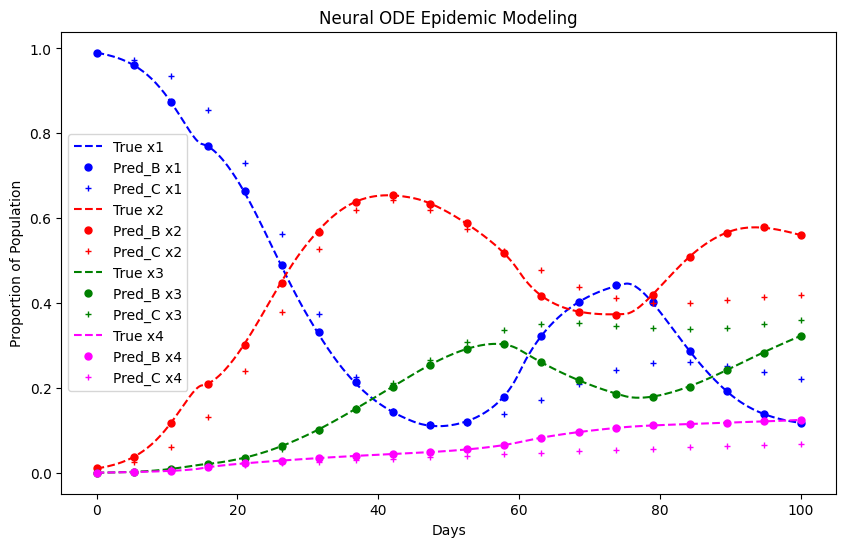

In [15]:
plt.figure(figsize=(10, 6))
labels = ['x1', 'x2', 'x3', 'x4']
colors = ['blue', 'red', 'green', 'magenta']
for i in range(4):
    plt.plot(t_data.cpu().numpy(), true_x[:, i].cpu().numpy(), label=f'True {labels[i]}', color=colors[i], linestyle='--')
    #plt.plot(t_span.cpu().numpy(), final_prediction_A[:, i].cpu().numpy(), label=f'Pred_A {labels[i]}', color=colors[i], marker ='x', markersize=5, linestyle ='None')
    plt.plot(t_span.cpu().numpy(), final_prediction_B[:, i].cpu().numpy(), label=f'Pred_B {labels[i]}', color=colors[i], marker ='o', markersize=5, linestyle ='None')
    plt.plot(t_span.cpu().numpy(), final_prediction_C[:, i].cpu().numpy(), label=f'Pred_C {labels[i]}', color=colors[i], marker ='+', markersize=5, linestyle ='None')


plt.title('Neural ODE Epidemic Modeling')
plt.xlabel('Days')
plt.ylabel('Proportion of Population')
plt.legend()
plt.show()

In [16]:
def compute_Tu_U_trajectory(func_model, t_series, x_series):
    tu_trajectory = []
    u_t_trajectory = [] # This will store u_t values where applicable
    t_series_device = t_series.to(device)
    x_series_device = x_series.to(device)

    for i in range(len(t_series_device)):
        t_val = t_series_device[i:i+1]
        x_val = x_series_device[i:i+1, :]

        with torch.no_grad():
            if isinstance(func_model, ODEFunc_CaseA) or isinstance(func_model, ODEFunc_CaseB) or isinstance(func_model, ODEFunc_CaseB_SoftBreakpoints):
                x_in, _, _, _, _ = _split_state(x_val)
                if isinstance(func_model, ODEFunc_CaseA):
                    u_t = func_model.u_interp(t_val).expand(x_in.shape[0], 1).to(x_in.dtype)
                else: # Case B or B_SoftBreakpoints
                    u_t = func_model.get_u(t_val).expand(x_in.shape[0], 1).to(x_in.dtype)
                inp = torch.cat([x_in, u_t], dim=1)
                tu_val = F.softplus(func_model.net_Tu(inp)) + 1e-3
                tu_trajectory.append(tu_val.item())
                u_t_trajectory.append(u_t.item()) # Append u_t for Cases A and B
            elif isinstance(func_model, ODEFunc_CaseC):
                # For Case C, u_t is a latent variable and not directly extracted in the same way
                x_augmented = x_val
                x, z = x_augmented[:, :4], x_augmented[:, 4:]
                inp = torch.cat([x, z], dim=1)
                fs_Tu = func_model.readout(inp)
                Tu_raw = fs_Tu[:, 1:2]
                tu_val = F.softplus(Tu_raw) + 1e-3
                tu_trajectory.append(tu_val.item())
                u_t = z # Append u_t for Case C
                u_t_trajectory.append(u_t.item()) # Placeholder for Case C where u_t isn't explicitly defined

    return torch.tensor(tu_trajectory), torch.tensor(u_t_trajectory, device=device)

In [17]:
# Compute Tu and u_t trajectories for plotting
#tu_trajectory_A, u_trajectory_A = compute_Tu_U_trajectory(func_A, t_span, final_prediction_A)
tu_trajectory_B, u_trajectory_B = compute_Tu_U_trajectory(func_B, t_span, final_prediction_B)
tu_trajectory_C, u_trajectory_C = compute_Tu_U_trajectory(func_C, t_span, final_prediction_C)

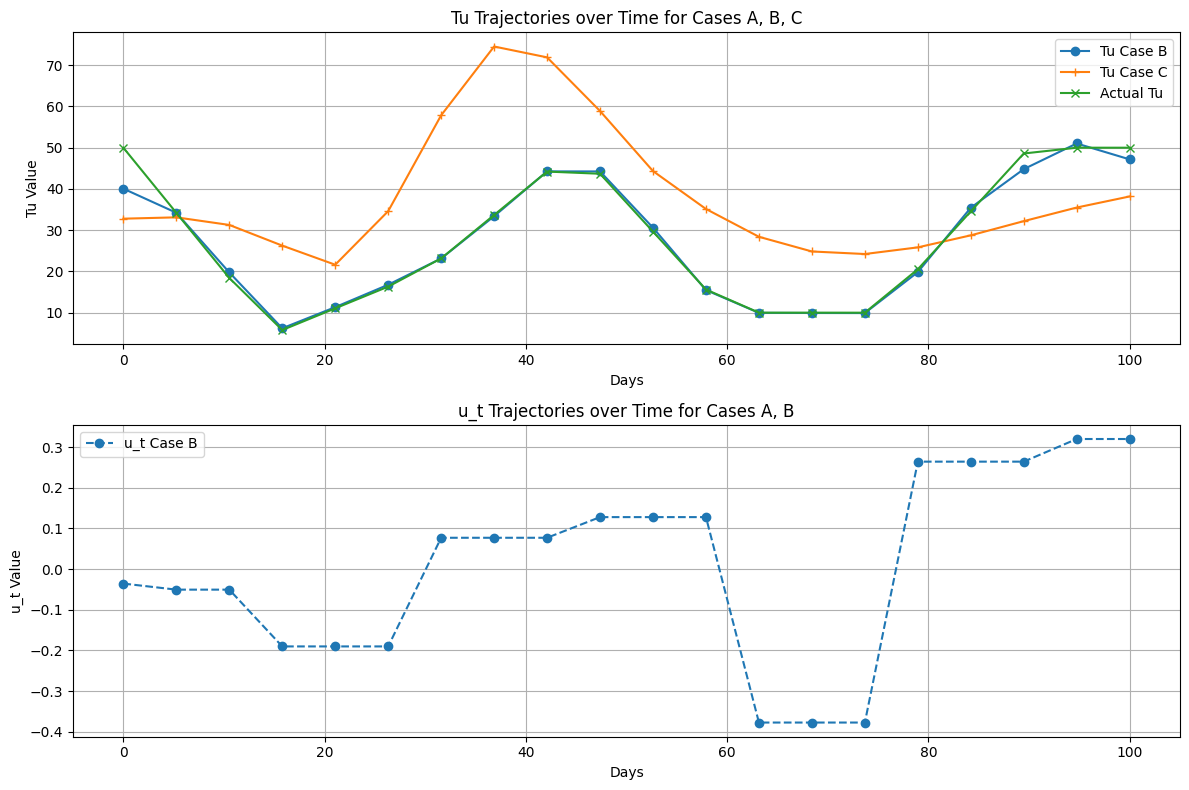

In [22]:
u_interp = LinearInterpolator(obs_times, obs_u)
#u_interp = CubicSplineInterpolator(obs_times, obs_u)

actual_tu_values = []
for t_val in t_span:
    u_val = u_interp(t_val) # This returns a tensor of shape (1,)
    # Use torch.min to handle tensors and ensure it's on the correct device
    tu = (1/2) * torch.min(u_val, torch.tensor(100.0, device=device))
    actual_tu_values.append(tu)
Actual_Tu = torch.cat(actual_tu_values) # Concatenate the (1,) tensors into a (N,) tensor

plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
#plt.plot(t_span.cpu().numpy(), tu_trajectory_A.cpu().numpy(), label='Tu Case A', marker='x')
plt.plot(t_span.cpu().numpy(), tu_trajectory_B.cpu().numpy(), label='Tu Case B', marker='o')
plt.plot(t_span.cpu().numpy(), tu_trajectory_C.cpu().numpy(), label='Tu Case C', marker='+')
plt.plot(t_span.cpu().numpy(), Actual_Tu.cpu().numpy(), label='Actual Tu', marker='x')
plt.title('Tu Trajectories over Time for Cases A, B, C')
plt.xlabel('Days')
plt.ylabel('Tu Value')
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
#plt.plot(t_span.cpu().numpy(), u_trajectory_A.cpu().numpy(), label='u_t Case A', marker='x', linestyle='--')
plt.plot(t_span.cpu().numpy(), u_trajectory_B.cpu().numpy(), label='u_t Case B', marker='o', linestyle='--')
# For Case C, u_t is not directly analogous, so it might show NaNs or zeros if plotted
# plt.plot(t_span.cpu().numpy(), u_trajectory_C.cpu().numpy(), label='u_t Case C', marker='+', linestyle='--')
plt.title('u_t Trajectories over Time for Cases A, B')
plt.xlabel('Days')
plt.ylabel('u_t Value')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()